In [1]:
import kwant
print("Kwant 版本:", kwant.__version__)

Kwant 版本: 1.5.0


In [2]:
import kwant

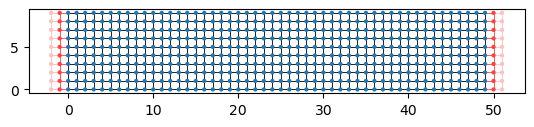

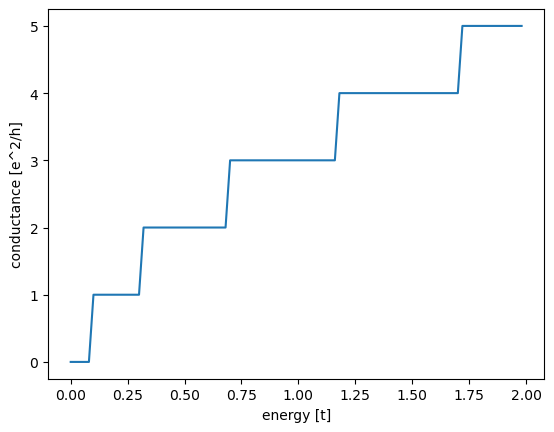

In [29]:
syst = kwant.Builder()
a = 1
lat = kwant.lattice.square(a, norbs=1)
t = 1.0
W, L = 10,50

# Define the scattering region
for i in range(L):
    for j in range(W):
        # On-site Hamiltonian
        syst[lat(i, j)] = 4 * t

        # Hopping in y-direction
        if j > 0:
            syst[lat(i, j), lat(i, j - 1)] = -t

        # Hopping in x-direction
        if i > 0:
            syst[lat(i, j), lat(i - 1, j)] = -t

#    syst[lat(i, 0), lat(i, W-1)] = -t
# 定义并附加引线：
# 先定义左引线（left lead）
# 注意：TranslationalSymmetry 接受实空间向量
sym_left_lead = kwant.TranslationalSymmetry((-a, 0))
left_lead = kwant.Builder(sym_left_lead)

for j in range(W):
    left_lead[lat(0, j)] = 4 * t

    if j > 0:
        left_lead[lat(0, j), lat(0, j - 1)] = -t

    left_lead[lat(1, j), lat(0, j)] = -t

# ===== y 方向周期边界（lead 里）=====
#left_lead[lat(0, 0), lat(0, W-1)] = -t

sym_right_lead = kwant.TranslationalSymmetry((a, 0))
right_lead = kwant.Builder(sym_right_lead)
for j in range(W):
    right_lead[lat(0, j)] = 4 * t

    if j > 0:
        right_lead[lat(0, j), lat(0, j - 1)] = -t

    right_lead[lat(1, j), lat(0, j)] = -t

# ===== y 方向周期边界（lead 里）=====
#right_lead[lat(0, 0), lat(0, W-1)] = -t


syst.attach_lead(left_lead)
syst.attach_lead(right_lead)
# 假设你的系统是 1D chain + 自旋 (norbs=2)
# lat = kwant.lattice.chain(norbs=2)
# syst[lat(0)] 是散射区最左格点
# lead 最后一个格点是 lead[lat(-1)] （因为 symmetry [-1]）

# 自定义跳跃矩阵（从 lead 到 syst[lat(0)]）
#custom_hop = -t * np.eye(2) + 1j * gamma_barrier * sigma_y  # 例如加势垒或 SOC

#syst.attach_lead(left_lead, hops={ (lat(-1), lat(0)): custom_hop })
kwant.plot(syst)
# Finalize the system
syst = syst.finalized()
# Now that we have the system, we can compute conductance
energies = []
data = []
for ie in range(100):
    energy = ie * 0.02

    # compute the scattering matrix at a given energy
    smatrix = kwant.smatrix(syst, energy)

    # compute the transmission probability from lead 0 to
    # lead 1
    energies.append(energy)
    data.append(smatrix.transmission(1, 0))
import matplotlib.pyplot as pyplot
# Use matplotlib to write output
# We should see conductance steps
pyplot.figure()
pyplot.plot(energies, data)
pyplot.xlabel("energy [t]")
pyplot.ylabel("conductance [e^2/h]")
pyplot.show()